In [1]:
from IPython.core.pylabtools import figsize

print("Hello,ecommerce analysis!")

Hello,ecommerce analysis!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import pymysql
plt.style.use("dark_background")



In [3]:
print("pandas",pd.__version__)
print("matplotlib imported successfully")
print("pymysql imported successfully")

pandas 2.3.3
matplotlib imported successfully
pymysql imported successfully


In [4]:
conn = pymysql.connect(
    host="localhost",
    user="root",
    password="REDACTED_PASSWORD",
    database="cross_border_ecommerce_db"
)
print("数据库连接成功")

数据库连接成功


In [5]:
query = "SHOW TABLES"
tables = pd.read_sql(query,conn)
print(tables)

  Tables_in_cross_border_ecommerce_db
0                        ad_campaigns
1                           logistics
2                              orders
3                            products
4                               users


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3612\2950785264.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(query,conn)


In [6]:
query = "SELECT * FROM orders"
df = pd.read_sql(query,conn)
print(df.head())

   order_id  user_id  product_id  order_date    country  quantity  unit_price  \
0      1001      101           1  2025-03-01        USA         2       39.99   
1      1002      102           2  2025-03-02    Germany         1       59.99   
2      1003      103           3  2025-03-03         UK         3       29.99   
3      1004      104           1  2025-03-04     Canada         1       39.99   
4      1005      105           4  2025-03-05  Australia         2       45.99   

   shopping_fee  
0           5.0  
1           8.0  
2           6.0  
3           7.0  
4          10.0  


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3612\3937150257.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      5 non-null      int64  
 1   user_id       5 non-null      int64  
 2   product_id    5 non-null      int64  
 3   order_date    5 non-null      object 
 4   country       5 non-null      object 
 5   quantity      5 non-null      int64  
 6   unit_price    5 non-null      float64
 7   shopping_fee  5 non-null      float64
dtypes: float64(2), int64(4), object(2)
memory usage: 448.0+ bytes
None


In [8]:
print(df.describe())

          order_id     user_id  product_id  quantity  unit_price  shopping_fee
count     5.000000    5.000000     5.00000   5.00000    5.000000      5.000000
mean   1003.000000  103.000000     2.20000   1.80000   43.190000      7.200000
std       1.581139    1.581139     1.30384   0.83666   11.009087      1.923538
min    1001.000000  101.000000     1.00000   1.00000   29.990000      5.000000
25%    1002.000000  102.000000     1.00000   1.00000   39.990000      6.000000
50%    1003.000000  103.000000     2.00000   2.00000   39.990000      7.000000
75%    1004.000000  104.000000     3.00000   2.00000   45.990000      8.000000
max    1005.000000  105.000000     4.00000   3.00000   59.990000     10.000000


In [9]:
df["sales"] = df["quantity"] * df["unit_price"]
print(df.head())

   order_id  user_id  product_id  order_date    country  quantity  unit_price  \
0      1001      101           1  2025-03-01        USA         2       39.99   
1      1002      102           2  2025-03-02    Germany         1       59.99   
2      1003      103           3  2025-03-03         UK         3       29.99   
3      1004      104           1  2025-03-04     Canada         1       39.99   
4      1005      105           4  2025-03-05  Australia         2       45.99   

   shopping_fee  sales  
0           5.0  79.98  
1           8.0  59.99  
2           6.0  89.97  
3           7.0  39.99  
4          10.0  91.98  


In [10]:
country_sales = df.groupby("country")["sales"].sum()
print(country_sales)

country
Australia    91.98
Canada       39.99
Germany      59.99
UK           89.97
USA          79.98
Name: sales, dtype: float64


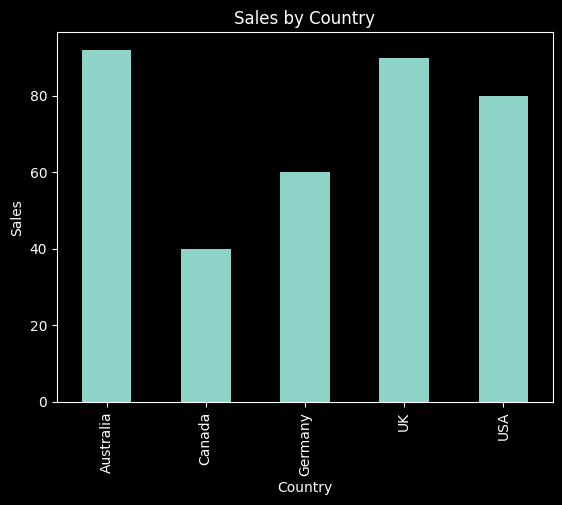

In [11]:
country_sales.plot(kind="bar")

plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales")

plt.show()



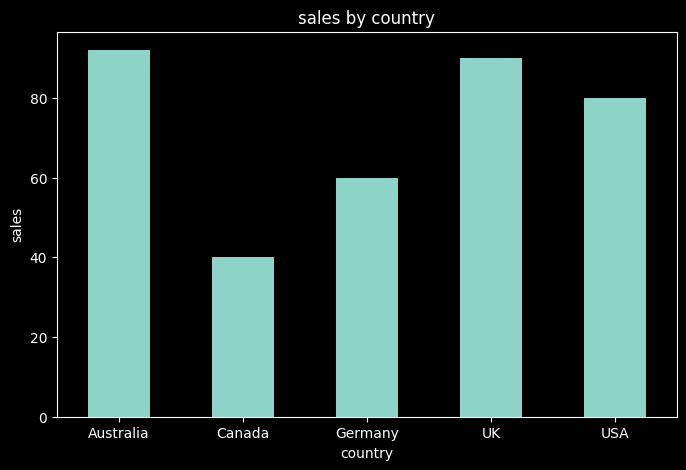

In [12]:
fig,ax = plt.subplots(figsize=(8,5))
country_sales.plot(kind="bar",ax=ax)

plt.title("sales by country")
plt.xlabel("country")
plt.ylabel("sales")

plt.xticks(rotation=0)
plt.show()


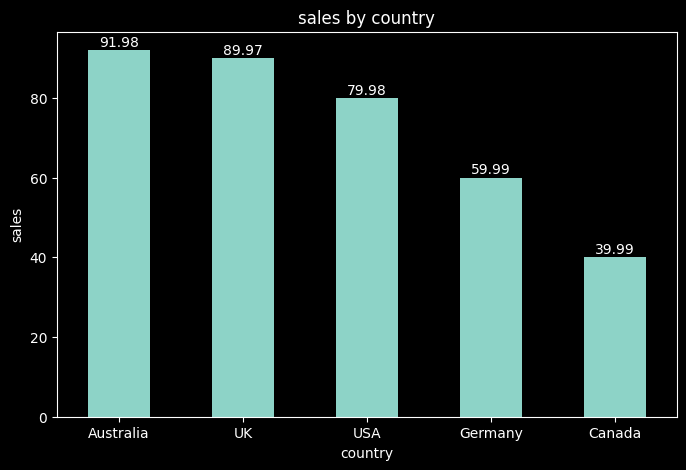

In [13]:
country_sales = country_sales.sort_values(ascending=False)
fig,ax = plt.subplots(figsize=(8,5))
country_sales.plot(kind="bar",ax=ax)

plt.title("sales by country")
plt.xlabel("country")
plt.ylabel("sales")

plt.xticks(rotation=0)

for i,v in enumerate(country_sales):
    ax.text(i,v+1,str(round(v,2)),ha="center")

plt.show()


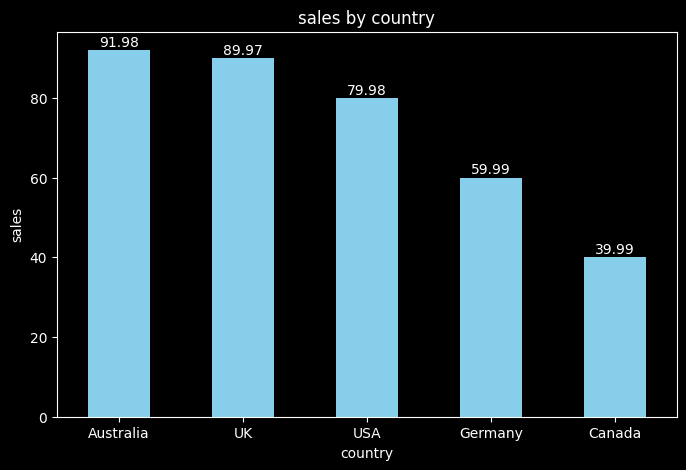

In [14]:
country_sales = country_sales.sort_values(ascending=False)
fig,ax = plt.subplots(figsize=(8,5))
country_sales.plot(
    kind="bar",
    ax=ax,
    color="skyblue"
)

plt.title("sales by country")
plt.xlabel("country")
plt.ylabel("sales")

plt.xticks(rotation=0)

for i,v in enumerate(country_sales):
    ax.text(i,v+1,str(round(v,2)),ha="center")

plt.savefig("../outputs/country_sales.png")
plt.show()

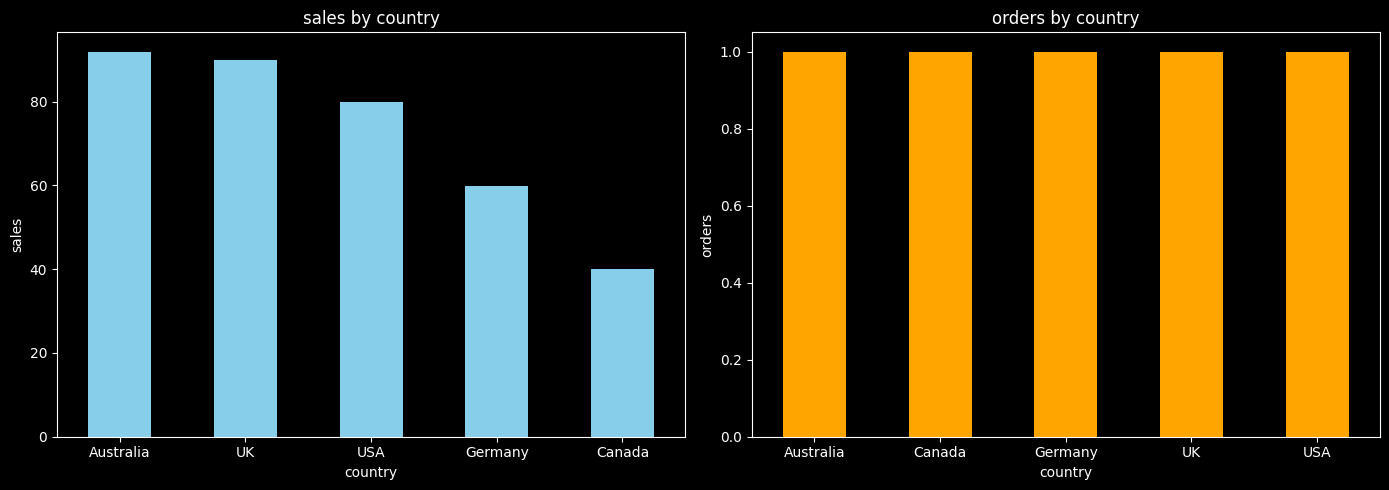

In [15]:
# 1.按国家统计销售额
country_sales =df.groupby("country")["sales"].sum().sort_values(ascending=False)
# 2.按国家统计订单数
country_orders =df.groupby("country")["order_id"].count().sort_values(ascending=False)
# 3.创建1行2列的画布
fig,axes = plt.subplots(1,2,figsize=(14,5))
# 图1：国家销售额柱状图
country_sales.plot(kind="bar",ax=axes[0],color="skyblue")
axes[0].set_title("sales by country")
axes[0].set_xlabel("country")
axes[0].set_ylabel("sales")
axes[0].tick_params(axis="x",rotation=0)
# 图2：国家订单数柱状图
country_orders.plot(
    kind="bar",
    ax=axes[1],
    color="orange"
)
axes[1].set_title("orders by country")
axes[1].set_xlabel("country")
axes[1].set_ylabel("orders")
axes[1].tick_params(axis="x",rotation=0)
# 自动调整布局
plt.tight_layout()
# 保存图片
plt.savefig("../outputs/country_dashboard.png")
# 图片展示
plt.show()

In [16]:
query = "SELECT * FROM ad_campaigns"
ad_df = pd.read_sql(query,conn)
print(ad_df.head())

   campaign_id       channel    country campaign_date  ad_cost  clicks  \
0          201    Google Ads        USA    2025-03-01    120.0     800   
1          202  Facebook Ads    Germany    2025-03-02     90.0     600   
2          203    Tiktok Ads         UK    2025-03-03     70.0     500   
3          204    Google Ads     Canada    2025-03-04     60.0     400   
4          205  Facebook Ads  Australia    2025-03-05     80.0     550   

   conversions  
0           25  
1           18  
2           15  
3           10  
4           12  


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3612\343268494.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ad_df = pd.read_sql(query,conn)


In [17]:
roi_df = pd.merge(
    country_sales.reset_index(),
    ad_df[["country","ad_cost"]],
    on="country"
)
print(roi_df)
roi_df["ROI"] = roi_df["sales"] / roi_df["ad_cost"]

roi_df = roi_df.sort_values(by="ROI",ascending=False)
print(roi_df)

     country  sales  ad_cost
0  Australia  91.98     80.0
1         UK  89.97     70.0
2        USA  79.98    120.0
3    Germany  59.99     90.0
4     Canada  39.99     60.0
     country  sales  ad_cost       ROI
1         UK  89.97     70.0  1.285286
0  Australia  91.98     80.0  1.149750
3    Germany  59.99     90.0  0.666556
2        USA  79.98    120.0  0.666500
4     Canada  39.99     60.0  0.666500


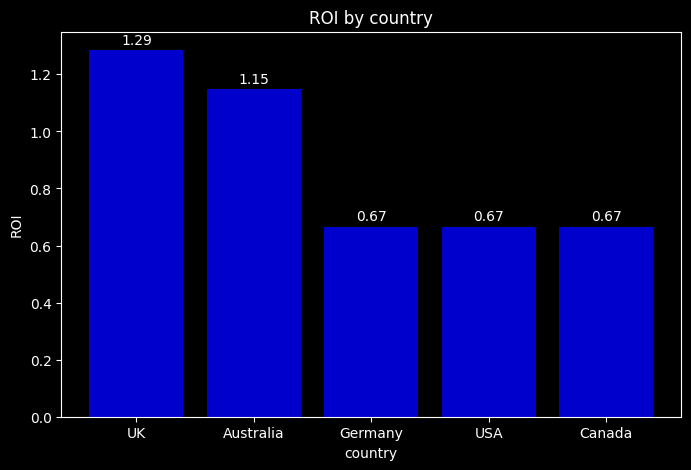

In [18]:
fig,ax = plt.subplots(figsize=(8,5))

ax.bar(
    roi_df["country"],
    roi_df["ROI"],
    color="mediumblue"
)

ax.set_title("ROI by country")
ax.set_xlabel("country")
ax.set_ylabel("ROI")

plt.xticks(rotation=0)

for i,v in enumerate(roi_df["ROI"]):
    ax.text(i,v+0.02,str(round(v,2)),ha="center")

plt.savefig("../outputs/roi_by_country.png")

In [19]:
ad_df["conversion_rate"] = (ad_df["conversions"] / ad_df["clicks"])
print(ad_df)

   campaign_id       channel    country campaign_date  ad_cost  clicks  \
0          201    Google Ads        USA    2025-03-01    120.0     800   
1          202  Facebook Ads    Germany    2025-03-02     90.0     600   
2          203    Tiktok Ads         UK    2025-03-03     70.0     500   
3          204    Google Ads     Canada    2025-03-04     60.0     400   
4          205  Facebook Ads  Australia    2025-03-05     80.0     550   

   conversions  conversion_rate  
0           25         0.031250  
1           18         0.030000  
2           15         0.030000  
3           10         0.025000  
4           12         0.021818  


In [20]:
ad_df["conversion_rate"] = (
    ad_df["conversions"] / ad_df["clicks"]
) * 100
print(ad_df[
    [
        "country",
        "clicks",
        "conversions",
        "conversion_rate"
    ]
      ])

     country  clicks  conversions  conversion_rate
0        USA     800           25         3.125000
1    Germany     600           18         3.000000
2         UK     500           15         3.000000
3     Canada     400           10         2.500000
4  Australia     550           12         2.181818


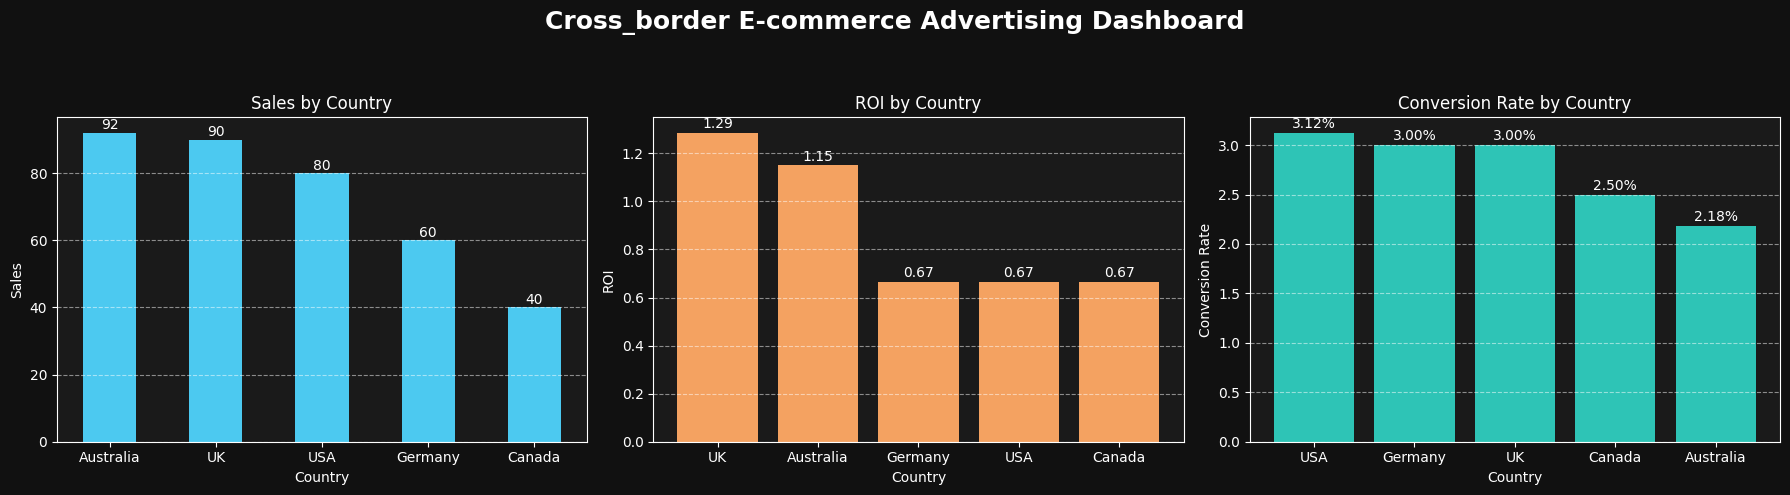

In [21]:
#做一个ad_dashboard,将销售额，投资回报率，点击转化率做成可展示的图标，并保存
country_sales = (
    df.groupby("country")["sales"].sum().sort_values(ascending=False)
)

roi_df = roi_df.sort_values(
    by="ROI",
    ascending=False
)

conversion_df = ad_df.sort_values(
    by="conversion_rate",
    ascending=False
)
#画布
fig,axes = plt.subplots(
    1,3,figsize=(18,5)
)
fig.patch.set_facecolor("#111111")
fig.suptitle(
    "Cross_border E-commerce Advertising Dashboard",
    fontsize=18,
    fontweight="bold",
    color="white"
)

for ax in axes:
    ax.set_facecolor("#1a1a1a")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

    for spine in ax.spines.values():
        spine.set_color("white")
#国家销售额图
country_sales.plot(
    kind="bar",
    ax=axes[0],
    color="#4cc9f0"
)
axes[0].set_title("Sales by Country")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Sales")
axes[0].tick_params(axis="x",rotation=0)
axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)
for i,v in enumerate(country_sales.values):
    axes[0].text(i,v+1,f"{v:.0f}",ha="center")
#ROI图
axes[1].bar(
    roi_df["country"],
    roi_df["ROI"],
    color="#f4a261"
)
axes[1].set_title("ROI by Country")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("ROI")
axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)
for i,v in enumerate(roi_df["ROI"]):
    axes[1].text(i,v+0.02,f"{v:.2f}",ha="center")
#conversion_rate图
axes[2].bar(
    conversion_df["country"],
    conversion_df["conversion_rate"],
    color="#2ec4b6"
)
axes[2].set_title("Conversion Rate by Country")
axes[2].set_xlabel("Country")
axes[2].set_ylabel("Conversion Rate")
axes[2].grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)
for i,v in enumerate(conversion_df["conversion_rate"]):\
    axes[2].text(i,v+0.05,f"{v:.2f}%",ha="center")

#自动布局
plt.tight_layout(rect=[0,0,1,0.92])

#保存图片
plt.savefig("../outputs/ad_dashboard.png")
plt.show()



# 广告投放分析结论

## 1. 销售额分析
澳大利亚和英国的销售表现最好，
销售额明显高于其他国家。

这说明：
这两个国家的市场需求较强，
产品在当地更容易被用户接受。

---

## 2. ROI（广告投资回报率）分析

英国和澳大利亚的ROI大于1，
说明广告投放效果较好。

广告投入能带来更高的销售回报，
当前广告策略具有较好的盈利能力。

而德国、美国、加拿大的ROI相对较低。

需要进一步分析：
-- 是否广告花费过高
-- 或销售转化效果不足

从而进一步优化广告预算和广告投放

---

## 3. 点击转化率分析

美国、德国、英国点击转化率较高。

说明这些国家用户：

-- 点击广告后的购买意愿较强
-- 广告内容与用户需求匹配度较高
-- 广告吸引力较强

而澳大利亚的转化率较低。

说明：
虽然销售额较高，
但用户点击后的转化率还有提升空间。

---

## 4. 商业建议

### （1）增加高 ROI 地区的广告投入
建议继续增加：

--英国
--澳大利亚
的广告预算。

因为这些地区的广澳收益较高，
具备进一步扩大市场的潜力。

---

###  （2）优化低 ROI 地区的广告策略

针对：
-- 德国
-- 美国
--加拿大
建议：
-优化广告素材
-调整广告手中
-改善产品页面
-提高广告精准度

从而降低无效广告支出

----

### （3）提升转化率

建议优化：
-商品详情页
-用户购买流程
-页面加载速度
-用户体验

提高用户最终下单率





In [22]:
from src.database import get_connection
conn = get_connection()
print("数据库连接成功")

数据库连接成功


In [23]:
from src.loader import load_orders
df = load_orders()
print(df.head())

   order_id  user_id  product_id  order_date    country  quantity  unit_price  \
0      1001      101           1  2025-03-01        USA         2       39.99   
1      1002      102           2  2025-03-02    Germany         1       59.99   
2      1003      103           3  2025-03-03         UK         3       29.99   
3      1004      104           1  2025-03-04     Canada         1       39.99   
4      1005      105           4  2025-03-05  Australia         2       45.99   

   shopping_fee  
0           5.0  
1           8.0  
2           6.0  
3           7.0  
4          10.0  


C:\code\ecommerce_analysis\src\loader.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


In [24]:
df["sales"] = df["unit_price"] * df["quantity"]
from src.analyzer import get_country_sales
country_sales = get_country_sales(df)
print(country_sales)

country
Australia    91.98
UK           89.97
USA          79.98
Germany      59.99
Canada       39.99
Name: sales, dtype: float64


In [25]:
from  src.analyzer import (
add_sales_column,get_country_sales
)
df = add_sales_column(df)
country_sales = get_country_sales(df)
print(country_sales)

country
Australia    91.98
UK           89.97
USA          79.98
Germany      59.99
Canada       39.99
Name: sales, dtype: float64


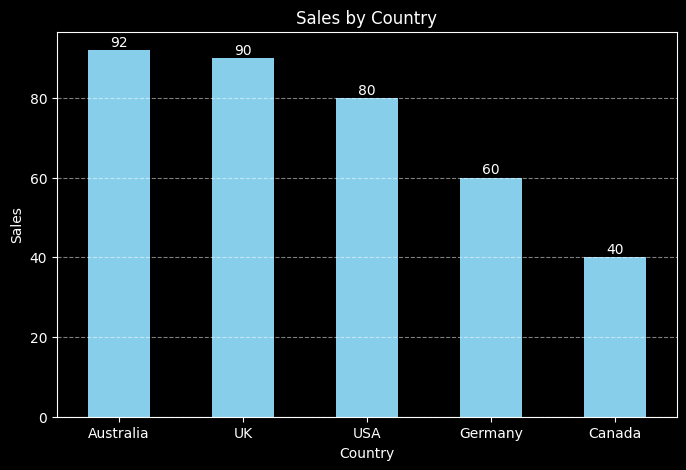

In [26]:
from src.visualizer import plot_country_sales
plot_country_sales(country_sales)

In [27]:
from src.loader import load_ads
from src.analyzer import calculate_roi

ad_df = load_ads()
roi_df = calculate_roi(country_sales,ad_df)
print(roi_df)

     country  sales  ad_cost       ROI
1         UK  89.97     70.0  1.285286
0  Australia  91.98     80.0  1.149750
3    Germany  59.99     90.0  0.666556
2        USA  79.98    120.0  0.666500
4     Canada  39.99     60.0  0.666500


C:\code\ecommerce_analysis\src\loader.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ad_df = pd.read_sql(query,conn)


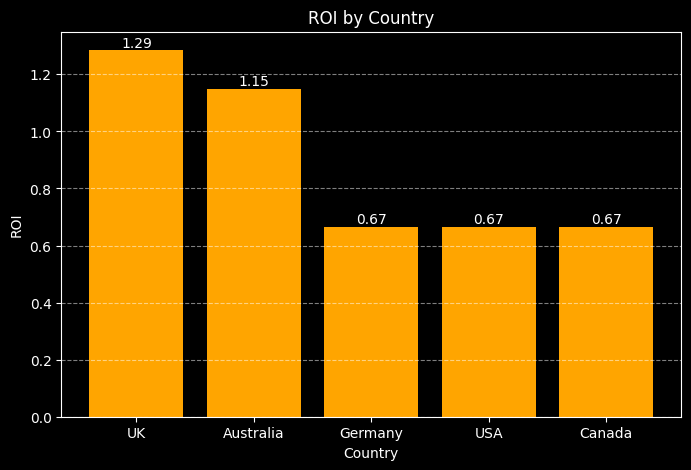

In [28]:
from src.visualizer import plot_roi_chart
plot_roi_chart(roi_df)

In [29]:
from src.analyzer import add_conversion_rate
conversion_df = add_conversion_rate(ad_df)
print(conversion_df[["country","clicks","conversions","conversion_rate"]])

     country  clicks  conversions  conversion_rate
0        USA     800           25         3.125000
1    Germany     600           18         3.000000
2         UK     500           15         3.000000
3     Canada     400           10         2.500000
4  Australia     550           12         2.181818


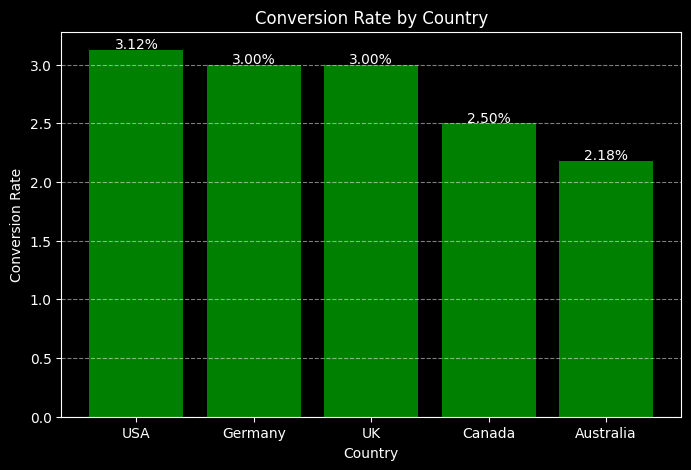

In [30]:
from src.visualizer import plot_conversion_rate
plot_conversion_rate(conversion_df)

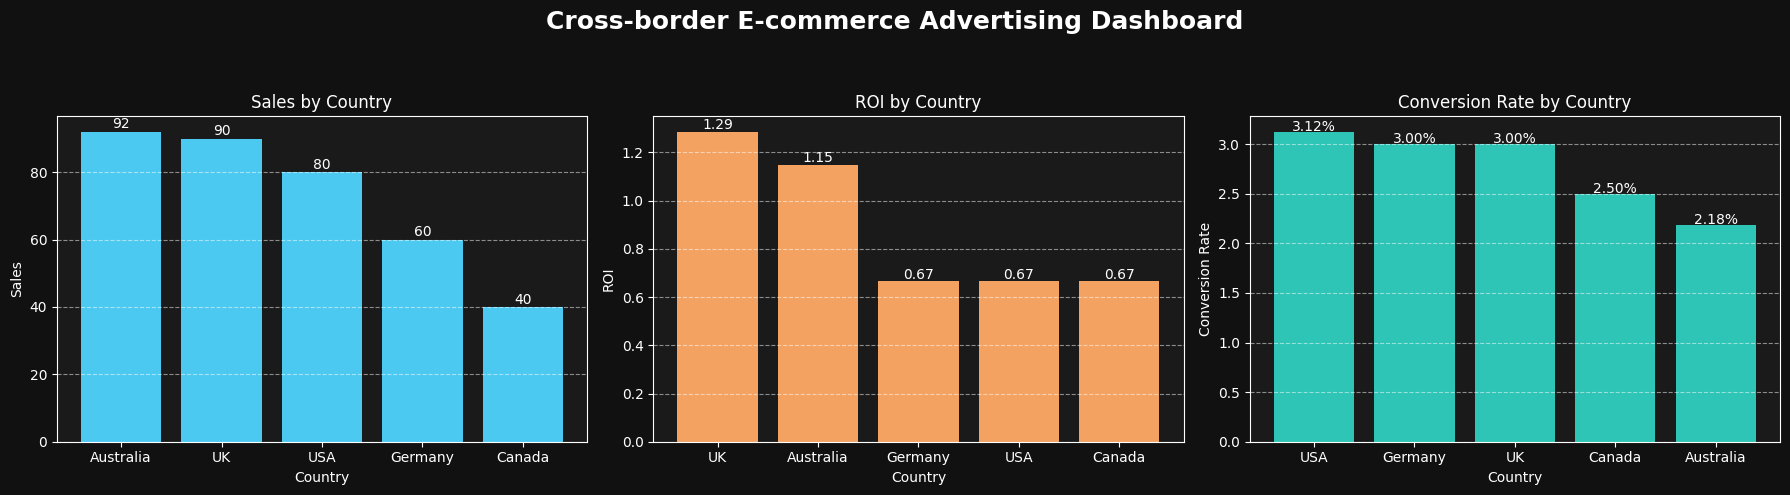

In [31]:
from src.visualizer import plot_ad_dashboard
plot_ad_dashboard(
    country_sales,
    roi_df,
    conversion_df)

C:\code\ecommerce_analysis\src\loader.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)
C:\code\ecommerce_analysis\src\loader.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ad_df = pd.read_sql(query,conn)


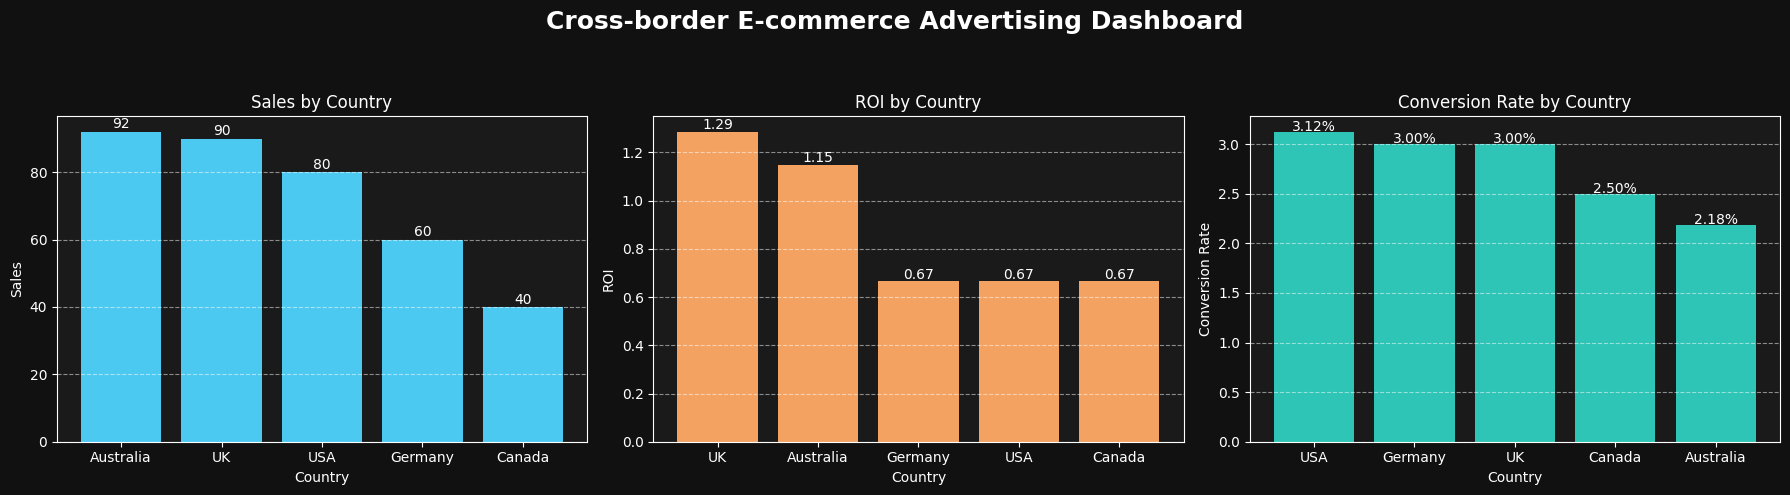

In [32]:
from src.loader import load_orders,load_ads
from src.analyzer import (
add_sales_column,
add_conversion_rate,
get_country_sales,
calculate_roi
)
from src.visualizer import plot_ad_dashboard

df = load_orders()
ad_df = load_ads()

df = add_sales_column(df)

country_sales = get_country_sales(df)
roi_df = calculate_roi(country_sales,ad_df)
conversion_df = add_conversion_rate(ad_df)

plot_ad_dashboard(
    country_sales,
    roi_df,
    conversion_df
)